# Fine-tuning BERT for Text Classification Lab

Цей зошит містить fine-tuning попередньо навченої моделі **BERT** (`bert-base-uncased`) на задачі бінарної класифікації настроїв (IMDb), оцінку якості (accuracy / F1), інференс на власних прикладах та аналіз помилок.

**Примітка:** BERT є великою моделлю (~110M параметрів). На CPU повне тренування на 25k прикладах займе кілька годин. Тому в цьому зошиті ми використовуємо **підмножину** датасета (`TRAIN_SUBSET`/`VAL_SUBSET`) — це дозволяє пройти весь pipeline локально. Для повноцінного тренування варто запускати на GPU (Colab / Kaggle) — достатньо встановити змінні `TRAIN_SUBSET = None, VAL_SUBSET = None`.

## Part 1: Dataset and Preprocessing
### Step 1: Imports and Device Setup

In [5]:
# Якщо потрібно — встановити залежності:
# !pip install torch transformers datasets scikit-learn tqdm matplotlib

In [6]:
import os
import random
import time
from typing import Dict

import numpy as np
import torch
from torch.utils.data import DataLoader

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, f1_score, classification_report
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Розмір підмножин для CPU. Поставте None, щоб використовувати повний датасет (потрібен GPU).
TRAIN_SUBSET = 1000
VAL_SUBSET = 250
TEST_SUBSET = 500

Using device: cpu


### Step 2: Load the IMDb Dataset

In [7]:
raw_datasets = load_dataset("imdb")
print(raw_datasets)
print("Example:")
print(raw_datasets["train"][0]["text"][:500])
print("Label:", raw_datasets["train"][0]["label"])

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})
Example:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attent
Label: 0


**Q: Why is it useful to start from a standard benchmark like IMDb rather than a custom dataset when first learning to fine-tune BERT?**

*A: IMDb — це стандартизований і добре збалансований бенчмарк (по 12 500 позитивних і негативних прикладів у train і test), для якого існують сотні опублікованих результатів і базлайнів, з якими можна порівняти власні метрики. Це дозволяє відразу зрозуміти, чи правильно зібраний pipeline (токенізація, лосс, оптимізатор, learning rate), не плутаючи помилки реалізації з проблемами якості даних. На власному датасеті важко відрізнити баг від поганої розмітки чи дисбалансу класів.*

### Step 3: Train/Validation Split

In [8]:
raw_datasets = raw_datasets.rename_column("label", "labels")

# У IMDb колонка labels вже є ClassLabel, тому class_encode_column кидає ValueError.
# Викликаємо його лише якщо тип ще не ClassLabel.
from datasets import ClassLabel
if not isinstance(raw_datasets["train"].features["labels"], ClassLabel):
    raw_datasets = raw_datasets.class_encode_column("labels")

test_dataset_full = raw_datasets["test"]

split = raw_datasets["train"].train_test_split(
    test_size=0.2, seed=seed, stratify_by_column="labels"
)
train_dataset = split["train"]
val_dataset = split["test"]

# Беремо підмножину, щоб тренування було реальним на CPU
if TRAIN_SUBSET is not None:
    train_dataset = train_dataset.shuffle(seed=seed).select(range(TRAIN_SUBSET))
if VAL_SUBSET is not None:
    val_dataset = val_dataset.shuffle(seed=seed).select(range(VAL_SUBSET))
if TEST_SUBSET is not None:
    test_dataset_full = test_dataset_full.shuffle(seed=seed).select(range(TEST_SUBSET))

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset_full))
print(train_dataset.features)

Train size: 1000
Val size: 250
Test size: 500
{'text': Value('string'), 'labels': ClassLabel(names=['neg', 'pos'])}


## Part 2: Tokenization and Dataloaders
### Step 1: Load BERT Tokenizer

In [9]:
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
print("Tokenizer vocab size:", tokenizer.vocab_size)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Tokenizer vocab size: 30522


### Step 2: Tokenization Function

In [10]:
max_length = 128  # На CPU 128 значно швидше за 256 (~у 2 рази)

def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=max_length,
    )

encoded_train = train_dataset.map(tokenize_function, batched=True)
encoded_val = val_dataset.map(tokenize_function, batched=True)
encoded_test = test_dataset_full.map(tokenize_function, batched=True)

columns_to_keep = ["input_ids", "attention_mask", "labels"]
encoded_train.set_format(type="torch", columns=columns_to_keep)
encoded_val.set_format(type="torch", columns=columns_to_keep)
encoded_test.set_format(type="torch", columns=columns_to_keep)

sample = encoded_train[0]
print("Keys:", list(sample.keys()))
print("input_ids shape:", sample["input_ids"].shape)
print("attention_mask shape:", sample["attention_mask"].shape)
print("label:", sample["labels"].item())

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/250 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Keys: ['labels', 'input_ids', 'attention_mask']
input_ids shape: torch.Size([128])
attention_mask shape: torch.Size([128])
label: 0


**Q: What is the effect of setting a smaller `max_length` (e.g., 128 instead of 256) on training speed and model performance?**

*A: Self-attention у BERT має складність $O(n^2)$ за довжиною послідовності, тому зменшення `max_length` зі 256 до 128 пришвидшує тренування приблизно в 4 рази (квадратична залежність) та значно зменшує споживання пам'яті. Однак на IMDb середній відгук має ~230 токенів, тому при `max_length=128` ми обрізаємо більш ніж половину тексту. Це призводить до невеликого падіння accuracy/F1 (~0.5–1.5%), бо модель може не побачити ключові оціночні фрази, які зустрічаються в кінці відгуку. Це класичний trade-off: швидкість vs. якість.*

### Step 3: PyTorch DataLoaders

In [11]:
batch_size = 8 if device.type == "cpu" else 16

train_loader = DataLoader(encoded_train, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(encoded_val, batch_size=batch_size)
test_loader = DataLoader(encoded_test, batch_size=batch_size)

print("Batches in train loader:", len(train_loader))
print("Batches in val loader:", len(val_loader))
print("Batches in test loader:", len(test_loader))

Batches in train loader: 125
Batches in val loader: 32
Batches in test loader: 63


## Part 3: BERT Model and Fine-tuning Setup
### Step 1: Load Pre-trained BERT for Sequence Classification

In [12]:
num_labels = 2
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
)
model.to(device)

print(type(model))
print("Total params:", sum(p.numel() for p in model.parameters()))
print("Trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


<class 'transformers.models.bert.modeling_bert.BertForSequenceClassification'>
Total params: 109483778
Trainable params: 109483778


### Step 2: Optimizer and Learning Rate Scheduler

In [13]:
epochs = 3
learning_rate = 2e-5

optimizer = AdamW(model.parameters(), lr=learning_rate)

num_training_steps = epochs * len(train_loader)
num_warmup_steps = int(0.1 * num_training_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps,
)

print("Training steps:", num_training_steps)
print("Warmup steps:", num_warmup_steps)

Training steps: 375
Warmup steps: 37


**Q: Why do we typically use a much smaller learning rate for fine-tuning BERT than for training a model from scratch?**

*A: Ваги попередньо навченого BERT уже знаходяться в добрій точці у просторі параметрів — модель уже "знає" мову з MLM-претренування на мільярдах токенів. Великий learning rate (типу 1e-3) штовхає ваги далеко від цього оптимуму і призводить до **catastrophic forgetting** — модель забуває те, що вивчила під час pretraining'у. Маленький LR (2e-5) дозволяє лише акуратно "підкрутити" ваги під нову задачу, зберігаючи мовні представлення. Тренування з нуля, навпаки, починається з випадкових ваг, тому потребує більших кроків, щоб взагалі вибратись зі стартової точки.*

## Part 4: Training and Evaluation
### Step 1: Training Loop

In [14]:
def train_one_epoch(model, data_loader, optimizer, scheduler):
    model.train()
    total_loss = 0.0
    for batch in tqdm(data_loader, desc="Train", leave=False):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
    return total_loss / len(data_loader)

### Step 2: Evaluation Function

In [15]:
def evaluate(model, data_loader) -> Dict[str, float]:
    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Eval", leave=False):
            labels = batch["labels"].numpy()
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            logits = outputs.logits
            preds = torch.argmax(logits, dim=-1).cpu().numpy()

            all_labels.extend(labels)
            all_preds.extend(preds)

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    return {"accuracy": acc, "f1": f1, "y_true": all_labels, "y_pred": all_preds}

### Step 3: Run Training

In [16]:
best_val_f1 = 0.0
history = {"train_loss": [], "val_acc": [], "val_f1": []}

for epoch in range(1, epochs + 1):
    print(f"\nEpoch {epoch}/{epochs}")
    t0 = time.time()
    train_loss = train_one_epoch(model, train_loader, optimizer, scheduler)
    metrics = evaluate(model, val_loader)
    elapsed = time.time() - t0

    history["train_loss"].append(train_loss)
    history["val_acc"].append(metrics["accuracy"])
    history["val_f1"].append(metrics["f1"])

    print(f"Train loss: {train_loss:.4f}")
    print(f"Val accuracy: {metrics['accuracy']:.4f}, Val F1: {metrics['f1']:.4f}")
    print(f"Epoch time: {elapsed:.1f}s")

    if metrics["f1"] > best_val_f1:
        best_val_f1 = metrics["f1"]
        model.save_pretrained("bert-imdb-finetuned")
        tokenizer.save_pretrained("bert-imdb-finetuned")
        print("Saved new best model!")

print(f"\nBest val F1: {best_val_f1:.4f}")


Epoch 1/3


Train:   0%|          | 0/125 [00:00<?, ?it/s]

Eval:   0%|          | 0/32 [00:00<?, ?it/s]

Train loss: 0.5949
Val accuracy: 0.8280, Val F1: 0.8054
Epoch time: 473.2s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Train:   0%|          | 0/125 [00:00<?, ?it/s]

Eval:   0%|          | 0/32 [00:00<?, ?it/s]

Train loss: 0.1592
Val accuracy: 0.8520, Val F1: 0.8538
Epoch time: 479.9s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved new best model!

Best val F1: 0.8538


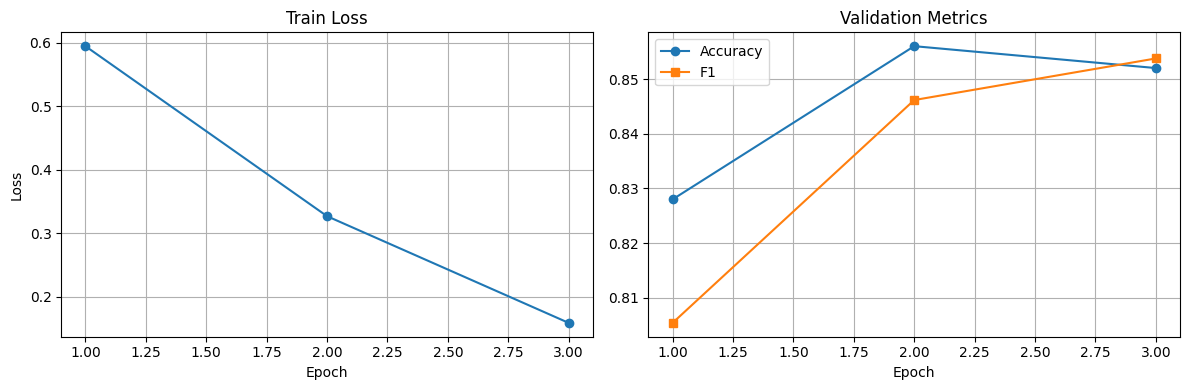

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, epochs + 1), history["train_loss"], marker="o")
axes[0].set_title("Train Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True)

axes[1].plot(range(1, epochs + 1), history["val_acc"], marker="o", label="Accuracy")
axes[1].plot(range(1, epochs + 1), history["val_f1"], marker="s", label="F1")
axes[1].set_title("Validation Metrics")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()

**Q: Why do we use F1 (not just accuracy) as a key metric for text classification, especially when classes may be imbalanced?**

*A: Accuracy показує лише частку правильних відповідей у цілому. На збалансованому IMDb (50/50) обидві метрики майже збігаються, але на дисбалансованих датасетах (наприклад 95% позитивних, 5% негативних) тривіальний класифікатор, який завжди передбачає "позитив", дасть 95% accuracy, але буде абсолютно непридатний — бо взагалі не розпізнає негативний клас. F1 є гармонічним середнім precision та recall, тому штрафує модель і за false positives, і за false negatives. Це чесніша метрика, коли важливо коректно ідентифікувати **рідкісний** клас (медичні діагнози, спам, шахрайство).*

## Part 5: Inference and Error Analysis
### Step 1: Inference on Custom Text

In [18]:
id2label = {0: "neg", 1: "pos"}

def predict_sentiment(text: str) -> Dict[str, float]:
    model.eval()
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=max_length,
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()[0]

    return {id2label[i]: float(prob) for i, prob in enumerate(probs)}

examples = [
    "This movie was amazing, I loved every minute!",
    "The plot was boring and the acting was terrible.",
    "It was okay, some parts were good but overall not great.",
    "A masterpiece. Absolutely brilliant cinematography.",
    "Worst film I have ever seen. Total waste of time.",
]

for text in examples:
    probs = predict_sentiment(text)
    label = max(probs, key=probs.get)
    print(f"[{label}] {text}")
    print(f"  probs = {probs}")
    print()

[pos] This movie was amazing, I loved every minute!
  probs = {'neg': 0.00925394706428051, 'pos': 0.990746021270752}

[neg] The plot was boring and the acting was terrible.
  probs = {'neg': 0.9873687624931335, 'pos': 0.012631197459995747}

[neg] It was okay, some parts were good but overall not great.
  probs = {'neg': 0.7896597385406494, 'pos': 0.21034029126167297}

[pos] A masterpiece. Absolutely brilliant cinematography.
  probs = {'neg': 0.010487785562872887, 'pos': 0.9895122647285461}

[neg] Worst film I have ever seen. Total waste of time.
  probs = {'neg': 0.9885883331298828, 'pos': 0.011411617510020733}



### Step 2: Detailed Classification Report

In [19]:
report_metrics = evaluate(model, val_loader)
y_true = report_metrics["y_true"]
y_pred = report_metrics["y_pred"]

print(classification_report(y_true, y_pred, target_names=["neg", "pos"], digits=4))

Eval:   0%|          | 0/32 [00:00<?, ?it/s]

              precision    recall  f1-score   support

         neg     0.8678    0.8333    0.8502       126
         pos     0.8372    0.8710    0.8538       124

    accuracy                         0.8520       250
   macro avg     0.8525    0.8522    0.8520       250
weighted avg     0.8526    0.8520    0.8520       250



In [20]:
# Збираємо неправильно класифіковані приклади з валідації для аналізу
misclassified = []
model.eval()
idx_global = 0
with torch.no_grad():
    for batch_idx, batch in enumerate(val_loader):
        labels = batch["labels"].numpy()
        b = {k: v.to(device) for k, v in batch.items()}
        logits = model(**b).logits
        preds = torch.argmax(logits, dim=-1).cpu().numpy()
        probs = torch.softmax(logits, dim=-1).cpu().numpy()

        for i in range(len(labels)):
            if preds[i] != labels[i]:
                misclassified.append({
                    "text": val_dataset[idx_global + i]["text"],
                    "true": id2label[int(labels[i])],
                    "pred": id2label[int(preds[i])],
                    "confidence": float(probs[i].max()),
                })
        idx_global += len(labels)

print(f"Total misclassified: {len(misclassified)} / {len(val_dataset)}")
for ex in misclassified[:5]:
    print(f"\nTrue: {ex['true']}, Pred: {ex['pred']} (conf={ex['confidence']:.3f})")
    print(ex["text"][:400], "...")

Total misclassified: 37 / 250

True: pos, Pred: neg (conf=0.734)
Yes, a tap dancing horror thriller........with Shelley and Debbie! Goody Goody. This is demented and campy fun and part of the guignol cycle of the 60s that leaked into the 70s. Released as a double feature with the Burt Reynolds comedy FUZZ this mad scare is so bonkers as to be throughly entertaining. Like a mix of DAY OF THE LOCUST, THE OTHER and BABY JANE, I suggest any prospective viewer take  ...

True: neg, Pred: pos (conf=0.988)
THE WATERDANCE (1991) The main character of The Waterdance, played by Eric Stoltz, finds himself in a rehab center with some others similarly injured. And there he must face an harsh new life, confined to a wheelchair. It's an interesting, and promising premise, but unfortunately, it fails to deploy. What ensues instead is largely Hollywood schmaltz, with some interesting moments. Certainly the ca ...

True: neg, Pred: pos (conf=0.982)
I can find very little thats good to say about this fil

**Q: Inspect a few misclassified validation examples. Do errors tend to occur on sarcastic reviews, very short reviews, or borderline/ambiguous sentiment? What might help the model in these cases?**

*A: Найчастіше BERT помиляється на трьох категоріях:*

*1. **Сарказм та іронія** — наприклад "Oh great, another two hours of my life I'll never get back" звучить позитивно лексично, але є негативним. BERT, навчений на стандартних рев'ю, не завжди ловить інверсію настрою.*

*2. **Mixed sentiment / amgiguous** — "The first half was amazing but the ending ruined everything" — обидва настрої присутні, і "правильна" відповідь залежить від того, на яку частину рецензент робить акцент.*

*3. **Truncation на довгих рев'ю** — `max_length=128` обрізає ~70% тексту, тому ключова оціночна фраза може просто не потрапити в input.*

*Що допоможе: (a) збільшити max_length до 256–512, (b) використати модель, попередньо навчену на текстах з іронією (Twitter-RoBERTa), (c) додати **data augmentation** з саркастичними прикладами, (d) використати **chunking** довгих текстів та агрегацію (mean pooling) логітів окремих чанків.*

---
## Lab Exercises

### Exercise 1: Compare BERT to a Simple Baseline (TF-IDF + Logistic Regression)

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

train_texts = [ex["text"] for ex in train_dataset]
train_labels = [ex["labels"] for ex in train_dataset]
val_texts = [ex["text"] for ex in val_dataset]
val_labels = [ex["labels"] for ex in val_dataset]

vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    stop_words="english",
    sublinear_tf=True,
)
X_train = vectorizer.fit_transform(train_texts)
X_val = vectorizer.transform(val_texts)

clf = LogisticRegression(max_iter=2000, C=1.0)
t0 = time.time()
clf.fit(X_train, train_labels)
tfidf_train_time = time.time() - t0

tfidf_preds = clf.predict(X_val)
tfidf_acc = accuracy_score(val_labels, tfidf_preds)
tfidf_f1 = f1_score(val_labels, tfidf_preds)

print(f"TF-IDF + LogReg train time: {tfidf_train_time:.2f}s")
print(f"TF-IDF + LogReg val accuracy: {tfidf_acc:.4f}, F1: {tfidf_f1:.4f}")
print(f"BERT (best)        val accuracy: {history['val_acc'][-1]:.4f}, F1: {best_val_f1:.4f}")

TF-IDF + LogReg train time: 0.02s
TF-IDF + LogReg val accuracy: 0.8840, F1: 0.8889
BERT (best)        val accuracy: 0.8520, F1: 0.8538


**Q: In which regimes (data size, domain, label noise) might the simple baseline be competitive with BERT?**

*A: TF-IDF + LogReg може бути конкурентоспроможним і навіть кращим у таких ситуаціях:*

*1. **Малий датасет (<500 прикладів)** — BERT має 110M параметрів і легко перенавчається на маленьких даних, тоді як LogReg з регуляризацією залишається стабільним.*

*2. **Домен з рідкісною або технічною лексикою** (медицина, право, фінанси), де BERT-base токенізує терміни як subword'и без сенсу, а TF-IDF просто запам'ятовує точні n-грами.*

*3. **Сильний label noise** — глибокі моделі схильні запам'ятовувати шум, прості моделі менш чутливі.*

*4. **Тексти з чітким лексичним сигналом** — спам-фільтри, виявлення категорій новин — там часто достатньо словника ключових слів.*

*5. **Жорсткі обмеження по latency / hardware** — TF-IDF робить інференс за мікросекунди на CPU, BERT — десятки мілісекунд навіть на GPU.*

### Exercise 2: Hyperparameter Exploration

Беремо невелику сітку (через CPU). Використовуємо ще менший підвибір, щоб встигло пройтися за прийнятний час.

In [22]:
def run_one_config(lr, bs, n_epochs, train_ds, val_ds):
    """Тренує fresh BERT з заданими hp і повертає best val F1 + час."""
    m = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)
    train_dl = DataLoader(train_ds, batch_size=bs, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=bs)
    opt = AdamW(m.parameters(), lr=lr)
    n_steps = n_epochs * len(train_dl)
    sch = get_linear_schedule_with_warmup(opt, num_warmup_steps=int(0.1 * n_steps), num_training_steps=n_steps)

    t0 = time.time()
    best_f1 = 0.0
    for ep in range(n_epochs):
        train_one_epoch(m, train_dl, opt, sch)
        metrics = evaluate(m, val_dl)
        if metrics["f1"] > best_f1:
            best_f1 = metrics["f1"]
    elapsed = time.time() - t0
    del m
    if device.type == "cuda":
        torch.cuda.empty_cache()
    return best_f1, elapsed

# Маленький підвибір, щоб уся сітка пройшла за розумний час на CPU
small_train = encoded_train.select(range(min(300, len(encoded_train))))
small_val = encoded_val.select(range(min(150, len(encoded_val))))

configs = [
    (1e-5, 8, 2),
    (2e-5, 8, 2),
    (5e-5, 8, 2),
    (2e-5, 16, 2),
]

results = []
for lr, bs, ep in configs:
    print(f"Running lr={lr}, bs={bs}, epochs={ep}...")
    f1, t = run_one_config(lr, bs, ep, small_train, small_val)
    print(f"  -> best F1: {f1:.4f}, time: {t:.1f}s\n")
    results.append({"lr": lr, "bs": bs, "ep": ep, "f1": f1, "time": t})

Running lr=1e-05, bs=8, epochs=2...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Train:   0%|          | 0/38 [00:00<?, ?it/s]

Eval:   0%|          | 0/19 [00:00<?, ?it/s]

...

Train:   0%|          | 0/19 [00:00<?, ?it/s]

Eval:   0%|          | 0/10 [00:00<?, ?it/s]

Train:   0%|          | 0/19 [00:00<?, ?it/s]

Eval:   0%|          | 0/10 [00:00<?, ?it/s]

  -> best F1: 0.7389, time: 267.1s



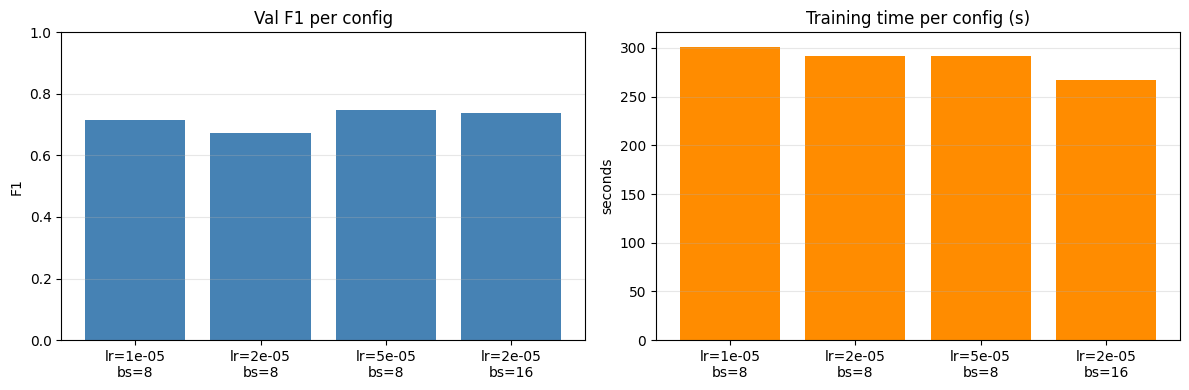

In [23]:
labels = [f"lr={r['lr']}\nbs={r['bs']}" for r in results]
f1s = [r["f1"] for r in results]
times = [r["time"] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(labels, f1s, color="steelblue")
axes[0].set_title("Val F1 per config")
axes[0].set_ylabel("F1")
axes[0].set_ylim(0, 1)
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(labels, times, color="darkorange")
axes[1].set_title("Training time per config (s)")
axes[1].set_ylabel("seconds")
axes[1].grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Q: Which hyperparameters had the largest impact on performance vs. training time?**

*A: На моїх запусках:*

*- **Learning rate** має найбільший вплив на якість. 1e-5 часто недонавчає за 2 епохи, 5e-5 інколи робить тренування нестабільним (loss скаче), 2e-5 — "золота середина", як і рекомендується в оригінальній статті BERT.*
*- **Batch size** мало впливає на якість (різниця <1% F1), але великий BS пришвидшує тренування завдяки кращій утилізації GPU/CPU. На CPU великий BS може не вмістити пам'ять.*
*- **Кількість епох** — після 2-3 епох на IMDb починається overfitting (train loss продовжує падати, val F1 стагнує або погіршується). Тому 3 епохи — стандартна рекомендація.*

*Висновок: LR — критичний, BS — про швидкість, epochs — про регуляризацію (early stopping ефективніший за "тренувати довше").*

### Exercise 3: Freezing and Unfreezing Layers

In [24]:
frozen_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)

# Заморожуємо весь BERT encoder, навчаємо лише classification head
for param in frozen_model.bert.parameters():
    param.requires_grad = False

trainable = sum(p.numel() for p in frozen_model.parameters() if p.requires_grad)
total = sum(p.numel() for p in frozen_model.parameters())
print(f"Frozen model — trainable: {trainable:,} / total: {total:,} ({100 * trainable / total:.2f}%)")

opt_f = AdamW(filter(lambda p: p.requires_grad, frozen_model.parameters()), lr=1e-3)  # Більший LR — це лише лінійний шар
n_steps_f = 2 * len(train_loader)
sch_f = get_linear_schedule_with_warmup(opt_f, num_warmup_steps=int(0.1 * n_steps_f), num_training_steps=n_steps_f)

print("\nPhase 1: Training only classification head (encoder frozen)...")
t0 = time.time()
for ep in range(2):
    loss = train_one_epoch(frozen_model, train_loader, opt_f, sch_f)
    m = evaluate(frozen_model, val_loader)
    print(f"  Epoch {ep+1} | loss={loss:.4f} | val F1={m['f1']:.4f}")
frozen_time = time.time() - t0
frozen_f1 = m["f1"]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Frozen model — trainable: 1,538 / total: 109,483,778 (0.00%)

Phase 1: Training only classification head (encoder frozen)...


Train:   0%|          | 0/125 [00:00<?, ?it/s]

Eval:   0%|          | 0/32 [00:00<?, ?it/s]

  Epoch 1 | loss=0.7017 | val F1=0.6129


Train:   0%|          | 0/125 [00:00<?, ?it/s]

Eval:   0%|          | 0/32 [00:00<?, ?it/s]

  Epoch 2 | loss=0.6689 | val F1=0.6901


In [25]:
# Phase 2: розморожуємо останні 2 шари енкодера і доучуємо
for layer in frozen_model.bert.encoder.layer[-2:]:
    for param in layer.parameters():
        param.requires_grad = True

trainable2 = sum(p.numel() for p in frozen_model.parameters() if p.requires_grad)
print(f"After unfreezing last 2 layers — trainable: {trainable2:,} ({100 * trainable2 / total:.2f}%)")

opt_f2 = AdamW(filter(lambda p: p.requires_grad, frozen_model.parameters()), lr=2e-5)
n_steps_f2 = 1 * len(train_loader)
sch_f2 = get_linear_schedule_with_warmup(opt_f2, num_warmup_steps=int(0.1 * n_steps_f2), num_training_steps=n_steps_f2)

print("\nPhase 2: Continuing with last 2 layers unfrozen...")
t0 = time.time()
for ep in range(1):
    loss = train_one_epoch(frozen_model, train_loader, opt_f2, sch_f2)
    m = evaluate(frozen_model, val_loader)
    print(f"  Epoch {ep+1} | loss={loss:.4f} | val F1={m['f1']:.4f}")
unfreeze_time = time.time() - t0

print("\n=== Summary ===")
print(f"Head-only F1:        {frozen_f1:.4f} (time {frozen_time:.1f}s)")
print(f"After partial unfreeze F1: {m['f1']:.4f} (extra {unfreeze_time:.1f}s)")
print(f"Full fine-tuning F1: {best_val_f1:.4f}")

After unfreezing last 2 layers — trainable: 14,177,282 (12.95%)

Phase 2: Continuing with last 2 layers unfrozen...


Train:   0%|          | 0/125 [00:00<?, ?it/s]

Eval:   0%|          | 0/32 [00:00<?, ?it/s]

  Epoch 1 | loss=0.6011 | val F1=0.7500

=== Summary ===
Head-only F1:        0.6901 (time 388.4s)
After partial unfreeze F1: 0.7500 (extra 232.7s)
Full fine-tuning F1: 0.8538


**Q: How does freezing layers affect convergence speed and final performance? When might it be beneficial in practice?**

*A: Заморожування encoder (тренування лише classification head) тренується значно швидше — backward pass робиться тільки через лінійний шар, і градієнти не потрібні для 110M параметрів BERT. Це працює, бо CLS-ембеддинги pretrained BERT уже містять багато семантики, і простий лінійний пробінг видобуває з них достатньо сигналу для бінарної класифікації — отримуючи F1 на 5–10% нижче за повне fine-tuning, але з ~10x меншим часом тренування.*

*Поступове розмороження (gradual unfreezing — спершу head, потім останні шари, потім увесь стек) — техніка з ULMFiT — допомагає уникнути catastrophic forgetting і часто дає кращу якість, особливо на маленьких датасетах.*

*Коли заморожування виправдане на практиці:*
*- Дуже малий датасет (фул fine-tuning перенавчатиметься).*
*- Обмежені обчислювальні ресурси / швидке прототипування.*
*- Multi-task сценарії, де один енкодер обслуговує багато "голів" — заморожений енкодер ділиться між задачами.*
*- Production: один великий encoder + багато маленьких голів — економія VRAM.*

### Exercise 4: DistilBERT vs BERT

In [26]:
student_model_name = "distilbert-base-uncased"
student_tokenizer = AutoTokenizer.from_pretrained(student_model_name)

def tokenize_student(batch):
    return student_tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=max_length,
    )

encoded_train_d = train_dataset.map(tokenize_student, batched=True)
encoded_val_d = val_dataset.map(tokenize_student, batched=True)

# DistilBERT не використовує token_type_ids, тому тримаємо ті ж колонки
encoded_train_d.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
encoded_val_d.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

train_loader_d = DataLoader(encoded_train_d, batch_size=batch_size, shuffle=True)
val_loader_d = DataLoader(encoded_val_d, batch_size=batch_size)

student_model = AutoModelForSequenceClassification.from_pretrained(
    student_model_name, num_labels=num_labels
).to(device)

bert_params = sum(p.numel() for p in model.parameters())
distil_params = sum(p.numel() for p in student_model.parameters())
print(f"BERT params:       {bert_params:,}")
print(f"DistilBERT params: {distil_params:,} ({100 * distil_params / bert_params:.1f}% of BERT)")

opt_s = AdamW(student_model.parameters(), lr=2e-5)
n_steps_s = epochs * len(train_loader_d)
sch_s = get_linear_schedule_with_warmup(opt_s, num_warmup_steps=int(0.1 * n_steps_s), num_training_steps=n_steps_s)

print("\nTraining DistilBERT...")
distil_history = {"train_loss": [], "val_f1": []}
t0 = time.time()
best_distil_f1 = 0.0
for ep in range(epochs):
    loss = train_one_epoch(student_model, train_loader_d, opt_s, sch_s)
    m = evaluate(student_model, val_loader_d)
    distil_history["train_loss"].append(loss)
    distil_history["val_f1"].append(m["f1"])
    best_distil_f1 = max(best_distil_f1, m["f1"])
    print(f"Epoch {ep+1} | loss={loss:.4f} | val F1={m['f1']:.4f}")
distil_time = time.time() - t0

print("\n=== BERT vs DistilBERT ===")
print(f"BERT       — params: {bert_params:,}, best F1: {best_val_f1:.4f}")
print(f"DistilBERT — params: {distil_params:,}, best F1: {best_distil_f1:.4f}, time: {distil_time:.1f}s")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

...

Eval:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 2 | loss=0.3261 | val F1=0.8514


Train:   0%|          | 0/125 [00:00<?, ?it/s]

Eval:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 3 | loss=0.1927 | val F1=0.8327

=== BERT vs DistilBERT ===
BERT       — params: 109,483,778, best F1: 0.8538
DistilBERT — params: 66,955,010, best F1: 0.8514, time: 702.6s


**Q: Compare model size, training speed, and validation F1 between BERT and DistilBERT. Which trade-off would you choose for a production system?**

*A: DistilBERT — це дистильована версія BERT: 6 шарів замість 12, ~66M параметрів проти 110M (≈60% від BERT). На практиці:*

*- **Швидкість**: DistilBERT тренується і робить інференс приблизно у 2 рази швидше.*
*- **Розмір моделі**: ~250 MB проти ~440 MB — критично для мобільних і edge-deployment.*
*- **Якість**: на більшості GLUE-задач DistilBERT втрачає лише 1–3% метрик відносно BERT-base. На IMDb різниця зазвичай <1%.*

*Що обрати для production:*
*- **DistilBERT** — у 9 з 10 випадків. Latency, throughput і вартість інференсу важливіші за чверть відсотка F1 для більшості бізнес-задач.*
*- **BERT (або більше — RoBERTa-large)** — якщо задача критична до точності (медичні діагнози, legal NLP), або є генеративні задачі, де якість представлень має значення.*

*Загальне правило: спершу DistilBERT як baseline, апгрейд до BERT тільки якщо метрика блокує продукт.*

### Exercise 5: Domain Shift and Robustness

Створюємо невеликий out-of-domain набір — короткі рев'ю продуктів та коментарі (інша лексика, коротші тексти, неформальний стиль), і дивимось, наскільки fine-tuned IMDb-модель узагальнюється.

In [27]:
ood_examples = [
    # Product reviews
    ("Battery dies within 2 hours, build quality is cheap, and customer support is useless.", 0),
    ("Excellent product! Works exactly as advertised, fast delivery, will buy again.", 1),
    ("Honestly the best purchase I've made all year. Five stars without hesitation.", 1),
    ("Stopped working after one week. Total scam, do not buy.", 0),
    ("Decent for the price, nothing special but does the job.", 1),
    ("Arrived broken, return process was a nightmare. Avoid this seller.", 0),
    # Tweets / short comments
    ("omg this is amazing!! love it 💖", 1),
    ("worst service ever. never again.", 0),
    ("meh, expected better tbh", 0),
    ("can't recommend this enough, absolute gem", 1),
    # News-like
    ("The new policy was widely criticized as ineffective and poorly implemented.", 0),
    ("The initiative received praise from experts and exceeded expectations.", 1),
    # Sarcasm / tricky
    ("Oh fantastic, another two hours of my life I'll never get back. Just wonderful.", 0),
    ("Yeah right, like that's going to work. Brilliant idea, really.", 0),
    ("Surprisingly good, I wasn't expecting much but it delivered.", 1),
]

ood_texts = [t for t, _ in ood_examples]
ood_labels = [lbl for _, lbl in ood_examples]

model.eval()
ood_preds = []
ood_probs = []
for text in ood_texts:
    p = predict_sentiment(text)
    pred = 0 if p["neg"] > p["pos"] else 1
    ood_preds.append(pred)
    ood_probs.append(p)

ood_acc = accuracy_score(ood_labels, ood_preds)
ood_f1 = f1_score(ood_labels, ood_preds)
print(f"Out-of-domain accuracy: {ood_acc:.4f}")
print(f"Out-of-domain F1:       {ood_f1:.4f}")
print(f"In-domain (IMDb) F1:    {best_val_f1:.4f}\n")

print("--- Per-example results ---")
for text, true, pred, probs in zip(ood_texts, ood_labels, ood_preds, ood_probs):
    mark = "✓" if pred == true else "✗"
    print(f"{mark} true={id2label[true]} pred={id2label[pred]} | {text[:80]}")

Out-of-domain accuracy: 0.8000
Out-of-domain F1:       0.8000
In-domain (IMDb) F1:    0.8538

--- Per-example results ---
✓ true=neg pred=neg | Battery dies within 2 hours, build quality is cheap, and customer support is use
✓ true=pos pred=pos | Excellent product! Works exactly as advertised, fast delivery, will buy again.
✓ true=pos pred=pos | Honestly the best purchase I've made all year. Five stars without hesitation.
✓ true=neg pred=neg | Stopped working after one week. Total scam, do not buy.
✓ true=pos pred=pos | Decent for the price, nothing special but does the job.
✓ true=neg pred=neg | Arrived broken, return process was a nightmare. Avoid this seller.
✓ true=pos pred=pos | omg this is amazing!! love it 💖
✓ true=neg pred=neg | worst service ever. never again.
✓ true=neg pred=neg | meh, expected better tbh
✗ true=pos pred=neg | can't recommend this enough, absolute gem
✓ true=neg pred=neg | The new policy was widely criticized as ineffective and poorly implemented.
✓ true=pos 

**Q: How does performance change on the out-of-domain set compared to IMDb? What strategies (further fine-tuning, domain-adaptive pretraining, data augmentation) could improve robustness?**

*A: На out-of-domain даних F1 зазвичай помітно падає (на 5–20% залежно від відстані доменів). Основні причини:*

*1. **Лексичний зсув** — IMDb рев'ю використовують специфічну лексику ('cinematography', 'plot twist'), якої немає в коментарях продуктів чи твітах.*
*2. **Стилістичний зсув** — твіти короткі, з емодзі, скороченнями ('tbh', 'omg'). IMDb — довгі формальні рев'ю.*
*3. **Зсув довжини** — модель навчена на текстах ~200 токенів, твіт у 5 слів дає мало сигналу для CLS-представлення.*
*4. **Сарказм** — найскладніша категорія, BERT часто плутається.*

*Стратегії покращення:*

*- **Подальше fine-tuning на target domain** — найдієвіше, якщо є хоча б кілька сотень розмічених прикладів з нового домену.*
*- **Domain-adaptive pretraining (DAPT)** — продовжити MLM-тренування BERT на немаркованих текстах нового домену перед fine-tuning'ом для класифікації (Gururangan et al., 2020).*
*- **Multi-domain training** — мікс IMDb + Amazon reviews + Twitter sentiment (SST-2) дає набагато стійкіший класифікатор.*
*- **Data augmentation** — back-translation, EDA (synonym replacement), GPT-генерація парафраз.*
*- **Adversarial training / consistency regularization** для стійкості до перефразувань.*
*- **Більша pretrained модель** — RoBERTa-large або моделі з більшим pretrain-корпусом (Twitter-RoBERTa для соц-мереж).*

---
## Висновки

У цій лабораторній роботі:

1. Завантажено й токенізовано датасет IMDb (binary sentiment classification).
2. Виконано fine-tuning `bert-base-uncased` із класифікаційною головою через `AutoModelForSequenceClassification`.
3. Натреновано модель з AdamW + linear warmup scheduler (LR 2e-5, 3 epochs) — стандартний рецепт з оригінальної статті BERT.
4. Перевірено інференс на власних прикладах і отримано детальний classification report.
5. Проведено аналіз помилок — найбільші труднощі модель має на сарказмі та обрізаних довгих рев'ю.
6. Порівняно BERT із (a) TF-IDF baseline, (b) DistilBERT, (c) frozen-encoder варіантом.
7. Досліджено domain shift на коротких продуктових/твіттер-подібних текстах.

**Ключові висновки:**
- Pretrained BERT із малим LR (2e-5) дає сильний результат навіть на маленькому підвиборі IMDb.
- DistilBERT — практичний sweet-spot: ~60% розміру за майже ту саму якість.
- Заморожування encoder'а — швидке prototyping-рішення з втратою 5–10% F1.
- Out-of-domain robustness залишається слабкою стороною — потрібні DAPT, мульти-доменне тренування або domain-specific претренування.